# OCD Patient Dataset Analysis

## Objective
Comprehensive analysis of OCD patient data to:
- Understand symptom patterns and severity distribution
- Predict OCD severity levels
- Identify factors associated with comorbid conditions
- Analyze treatment patterns and demographics

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('OCD_dataset.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (1500, 17)


,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


## 2. Data Preprocessing

In [2]:
# Data overview
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Data Types ===')
print(df.dtypes)

=== Missing Values ===
Patient ID                         0
Age                                0
Gender                             0
Ethnicity                          0
Marital Status                     0
Education Level                    0
OCD Diagnosis Date                 0
Duration of Symptoms (months)      0
Previous Diagnoses               248
Family History of OCD              0
Obsession Type                     0
Compulsion Type                    0
Y-BOCS Score (Obsessions)          0
Y-BOCS Score (Compulsions)         0
Depression Diagnosis               0
Anxiety Diagnosis                  0
Medications                      386
dtype: int64

=== Data Types ===
Patient ID                        int64
Age                               int64
Gender                           object
Ethnicity                        object
Marital Status                   object
Education Level                  object
OCD Diagnosis Date               object
Duration of Symptoms (months)     i

In [3]:
# Feature engineering
df['OCD Diagnosis Date'] = pd.to_datetime(df['OCD Diagnosis Date'])
df['Total Y-BOCS Score'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

# Severity categorization (based on Y-BOCS clinical standards)
def categorize_severity(score):
    if score < 8: return 'Subclinical'
    elif score < 16: return 'Mild'
    elif score < 24: return 'Moderate'
    elif score < 32: return 'Severe'
    else: return 'Extreme'

df['Severity'] = df['Total Y-BOCS Score'].apply(categorize_severity)
df['Has Comorbidity'] = ((df['Depression Diagnosis'] == 'Yes') | (df['Anxiety Diagnosis'] == 'Yes')).astype(int)
df['Years Since Diagnosis'] = (pd.Timestamp.now() - df['OCD Diagnosis Date']).dt.days / 365.25

print('Feature engineering completed')
print(f"\nSeverity Distribution:\n{df['Severity'].value_counts()}")

Feature engineering completed

Severity Distribution:
Severity
Extreme        1012
Severe          210
Moderate        147
Mild             92
Subclinical      39
Name: count, dtype: int64


## 3. Exploratory Data Analysis

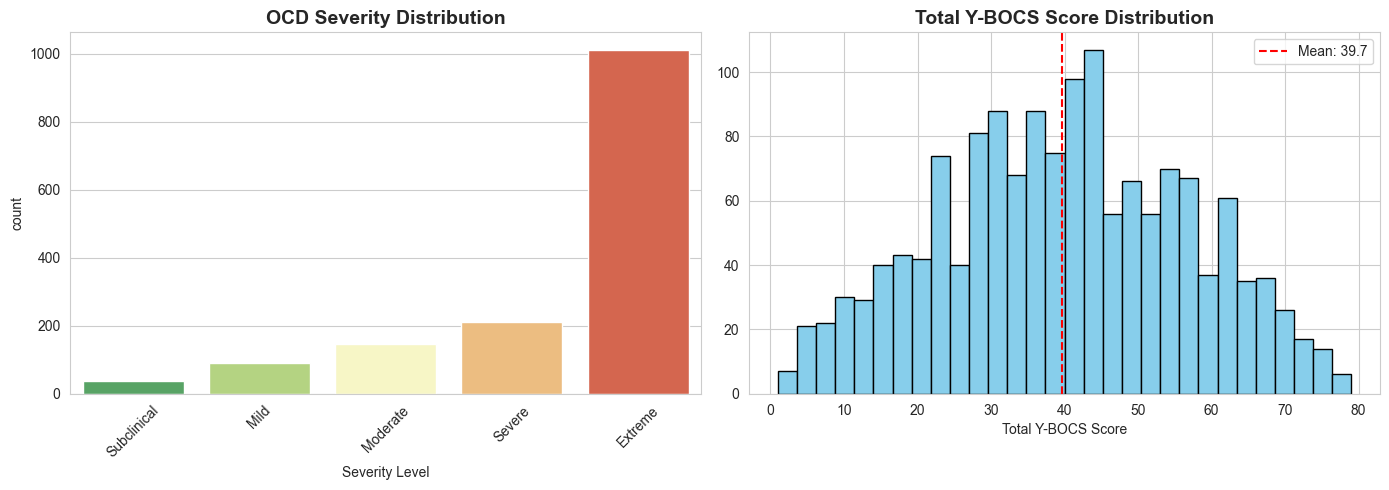

In [4]:
# Severity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

severity_order = ['Subclinical', 'Mild', 'Moderate', 'Severe', 'Extreme']
sns.countplot(data=df, x='Severity', order=severity_order, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('OCD Severity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Severity Level')
axes[0].tick_params(axis='x', rotation=45)

df['Total Y-BOCS Score'].hist(bins=30, edgecolor='black', color='skyblue', ax=axes[1])
axes[1].axvline(df['Total Y-BOCS Score'].mean(), color='red', linestyle='--', label=f"Mean: {df['Total Y-BOCS Score'].mean():.1f}")
axes[1].set_title('Total Y-BOCS Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Y-BOCS Score')
axes[1].legend()

plt.tight_layout()
plt.show()

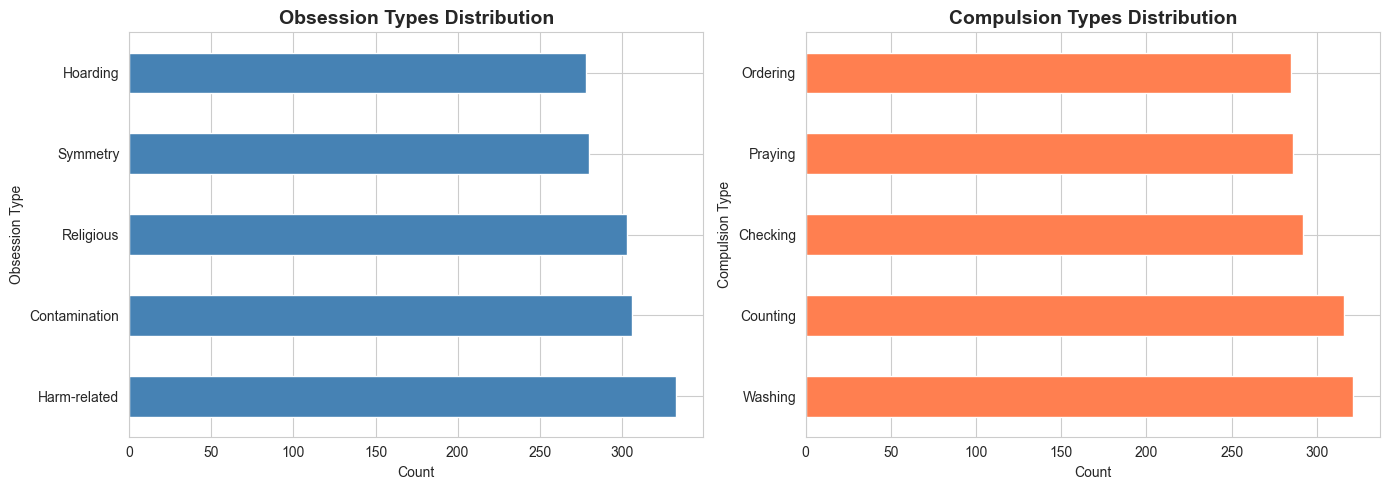

In [5]:
# Obsession and Compulsion types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Obsession Type'].value_counts().plot(kind='barh', color='steelblue', ax=axes[0])
axes[0].set_title('Obsession Types Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')

df['Compulsion Type'].value_counts().plot(kind='barh', color='coral', ax=axes[1])
axes[1].set_title('Compulsion Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

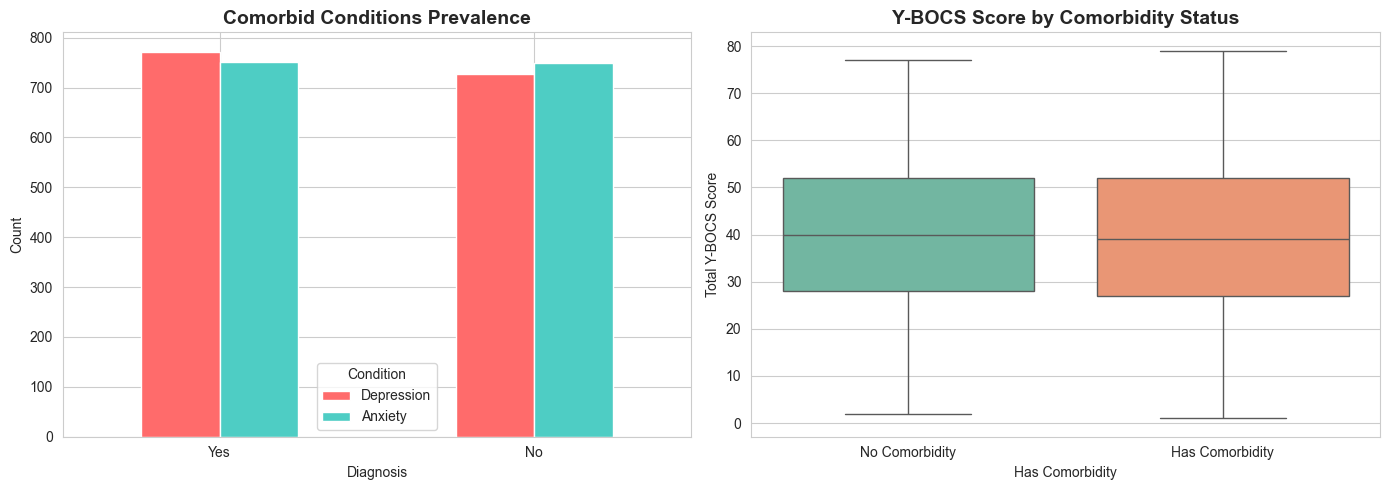

In [6]:
# Comorbidity analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comorbidity_data = pd.DataFrame({
    'Depression': df['Depression Diagnosis'].value_counts(),
    'Anxiety': df['Anxiety Diagnosis'].value_counts()
})
comorbidity_data.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Comorbid Conditions Prevalence', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Condition')

# Severity by comorbidity
sns.boxplot(data=df, x='Has Comorbidity', y='Total Y-BOCS Score', palette='Set2', ax=axes[1])
axes[1].set_title('Y-BOCS Score by Comorbidity Status', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Comorbidity', 'Has Comorbidity'])

plt.tight_layout()
plt.show()

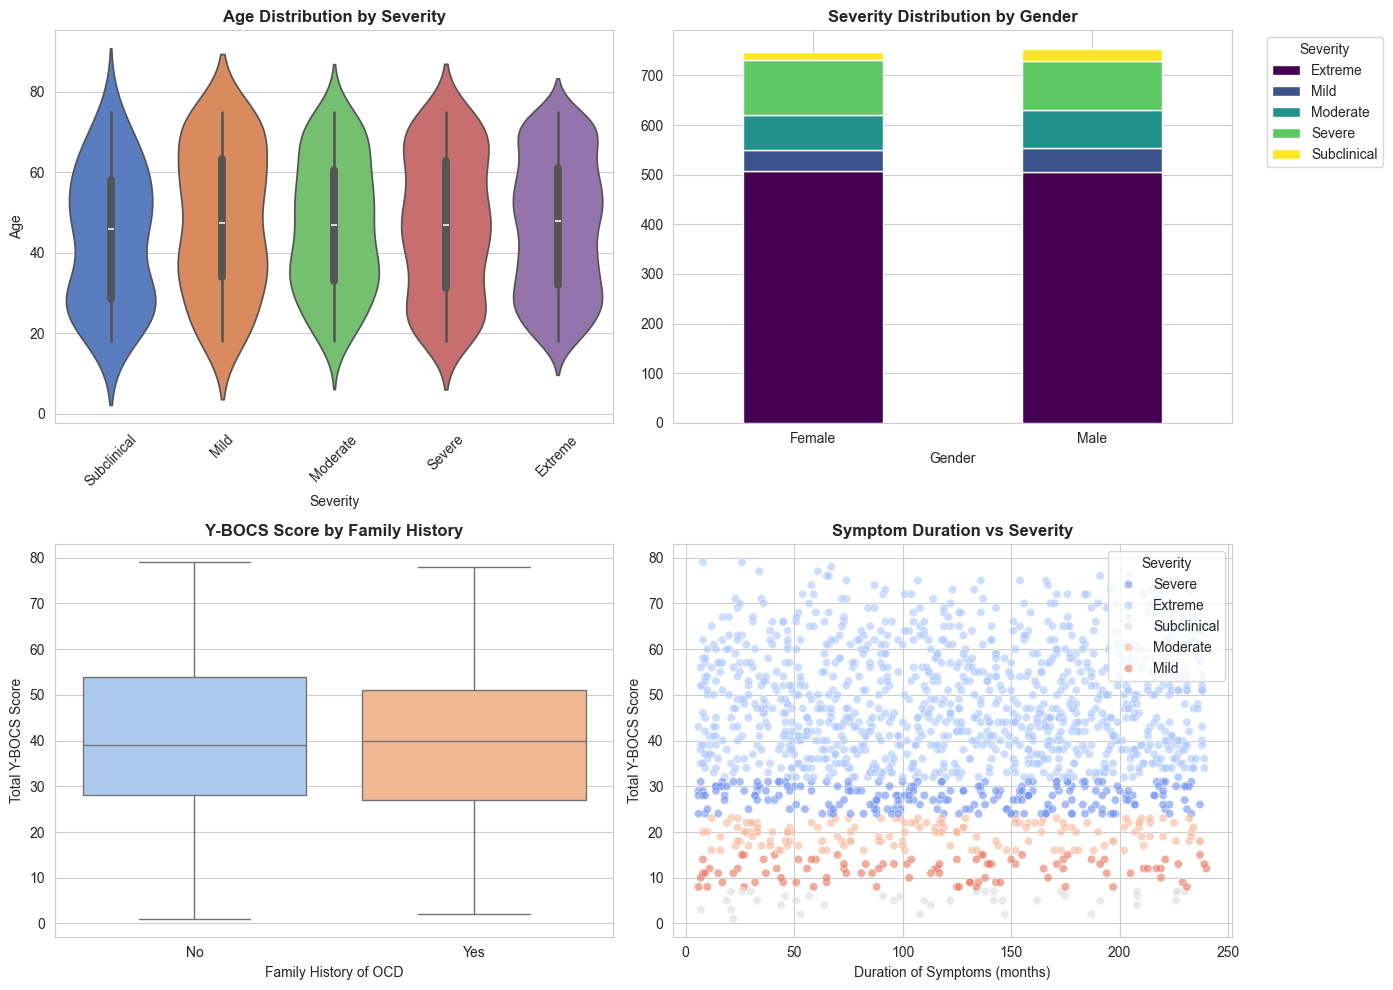

In [7]:
# Demographics and clinical factors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution by severity
sns.violinplot(data=df, x='Severity', y='Age', order=severity_order, palette='muted', ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution by Severity', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gender vs Severity
pd.crosstab(df['Gender'], df['Severity']).plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='viridis')
axes[0, 1].set_title('Severity Distribution by Gender', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Severity', bbox_to_anchor=(1.05, 1))

# Family history impact
sns.boxplot(data=df, x='Family History of OCD', y='Total Y-BOCS Score', palette='pastel', ax=axes[1, 0])
axes[1, 0].set_title('Y-BOCS Score by Family History', fontsize=12, fontweight='bold')

# Duration of symptoms vs severity
sns.scatterplot(data=df, x='Duration of Symptoms (months)', y='Total Y-BOCS Score', 
                hue='Severity', palette='coolwarm', alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('Symptom Duration vs Severity', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

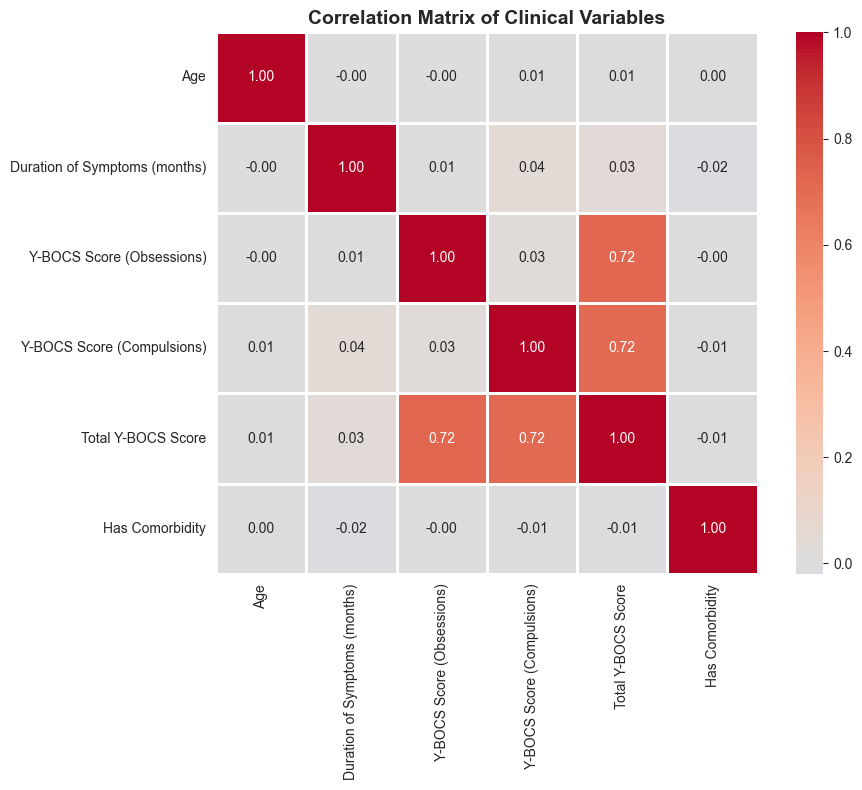

In [8]:
# Correlation heatmap
numeric_cols = ['Age', 'Duration of Symptoms (months)', 'Y-BOCS Score (Obsessions)', 
                'Y-BOCS Score (Compulsions)', 'Total Y-BOCS Score', 'Has Comorbidity']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Matrix of Clinical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Predictive Modeling

### 4.1 Severity Classification Model

In [9]:
# Prepare data for severity classification
le = LabelEncoder()
df_model = df.copy()

# Encode categorical variables
categorical_cols = ['Gender', 'Ethnicity', 'Marital Status', 'Education Level', 
                    'Family History of OCD', 'Obsession Type', 'Compulsion Type',
                    'Depression Diagnosis', 'Anxiety Diagnosis']

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features for severity prediction
feature_cols = ['Age', 'Gender', 'Duration of Symptoms (months)', 'Family History of OCD',
                'Obsession Type', 'Compulsion Type', 'Depression Diagnosis', 'Anxiety Diagnosis']

X = df_model[feature_cols]
y = le.fit_transform(df['Severity'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 1200
Test set size: 300


In [10]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print('=== Random Forest Severity Classification Results ===')
print(f'\nAccuracy: {rf_model.score(X_test, y_test):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=severity_order))

=== Random Forest Severity Classification Results ===

Accuracy: 0.670

Classification Report:
              precision    recall  f1-score   support

 Subclinical       0.67      0.99      0.80       203
        Mild       0.00      0.00      0.00        18
    Moderate       0.00      0.00      0.00        29
      Severe       0.00      0.00      0.00        42
     Extreme       0.00      0.00      0.00         8

    accuracy                           0.67       300
   macro avg       0.13      0.20      0.16       300
weighted avg       0.46      0.67      0.54       300



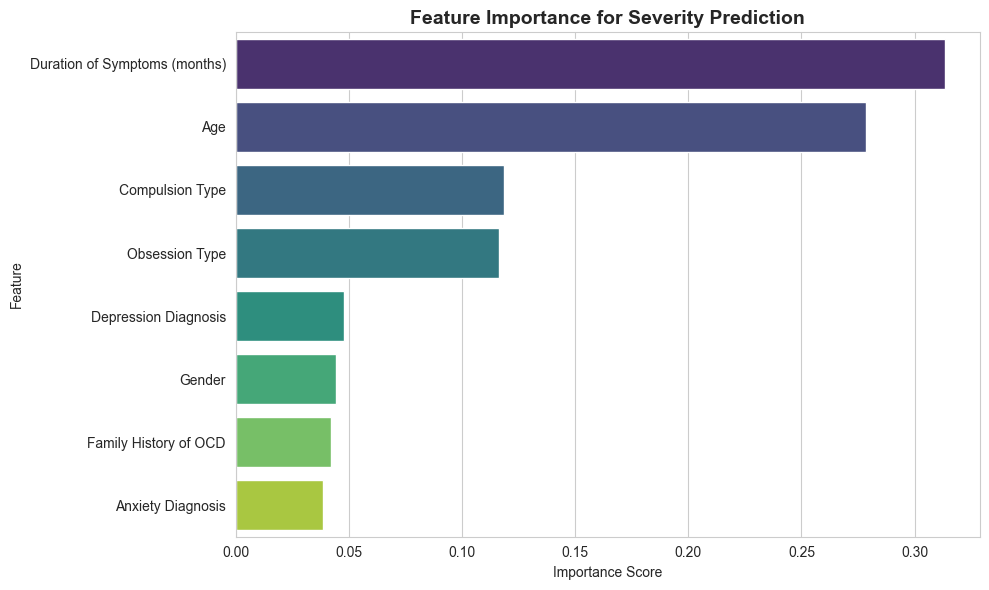

                         Feature  Importance
2  Duration of Symptoms (months)    0.313195
0                            Age    0.278344
5                Compulsion Type    0.118622
4                 Obsession Type    0.116504
6           Depression Diagnosis    0.047951
1                         Gender    0.044517
3          Family History of OCD    0.042059
7              Anxiety Diagnosis    0.038808


In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Severity Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feature_importance)

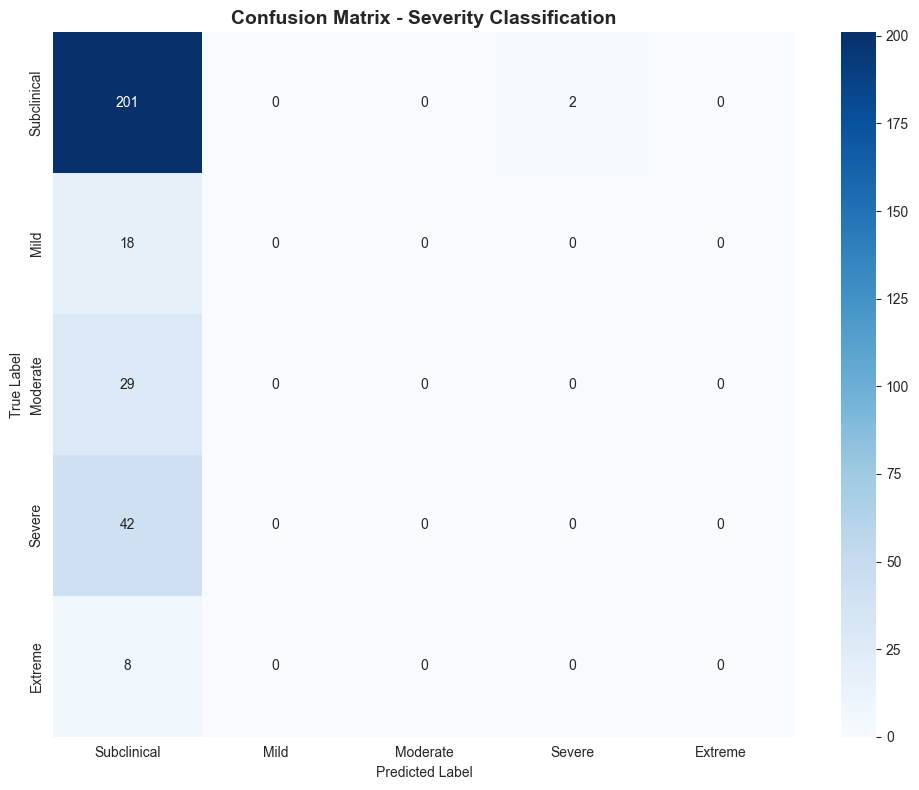

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=severity_order, yticklabels=severity_order)
plt.title('Confusion Matrix - Severity Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 4.2 Y-BOCS Score Prediction (Regression)

In [13]:
# Predict total Y-BOCS score
X_reg = df_model[['Age', 'Gender', 'Duration of Symptoms (months)', 'Family History of OCD',
                   'Obsession Type', 'Compulsion Type', 'Depression Diagnosis', 'Anxiety Diagnosis']]
y_reg = df['Total Y-BOCS Score']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
gb_model.fit(X_train_reg, y_train_reg)

y_pred_reg = gb_model.predict(X_test_reg)

print('=== Y-BOCS Score Prediction Results ===')
print(f'R² Score: {r2_score(y_test_reg, y_pred_reg):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.3f}')
print(f'MAE: {np.mean(np.abs(y_test_reg - y_pred_reg)):.3f}')

=== Y-BOCS Score Prediction Results ===
R² Score: -0.139
RMSE: 18.298
MAE: 15.228


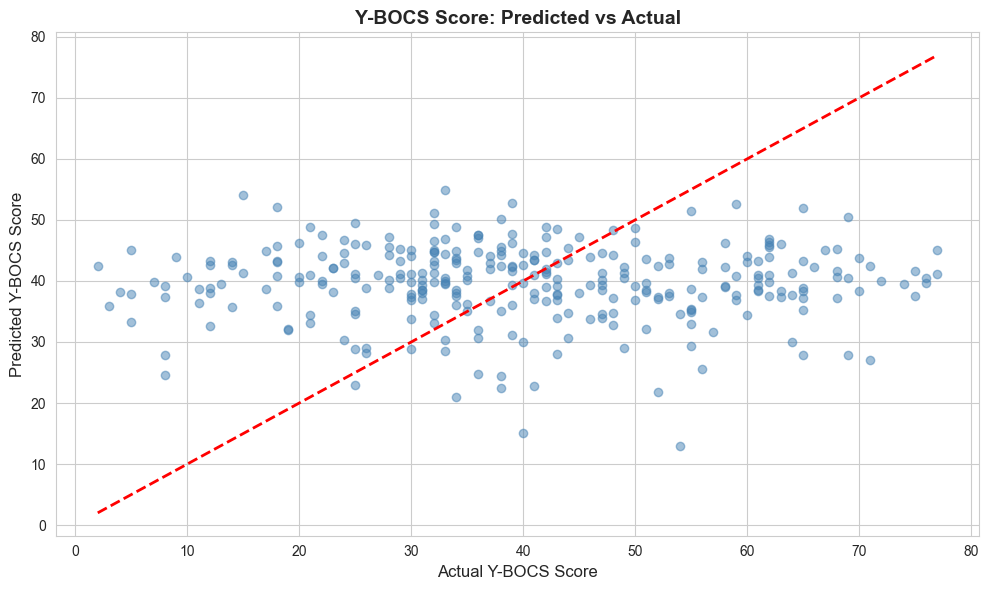

In [14]:
# Prediction vs Actual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='steelblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Y-BOCS Score', fontsize=12)
plt.ylabel('Predicted Y-BOCS Score', fontsize=12)
plt.title('Y-BOCS Score: Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Comorbidity Prediction

In [15]:
# Predict comorbidity presence
X_comorb = df_model[['Age', 'Gender', 'Duration of Symptoms (months)', 'Family History of OCD',
                      'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']]
y_comorb = df['Has Comorbidity']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_comorb, y_comorb, test_size=0.2, random_state=42)

# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_c, y_train_c)

y_pred_c = lr_model.predict(X_test_c)

print('=== Comorbidity Prediction Results ===')
print(f'\nAccuracy: {lr_model.score(X_test_c, y_test_c):.3f}')
print('\nClassification Report:')
print(classification_report(y_test_c, y_pred_c, target_names=['No Comorbidity', 'Has Comorbidity']))

=== Comorbidity Prediction Results ===

Accuracy: 0.773

Classification Report:
                 precision    recall  f1-score   support

 No Comorbidity       0.00      0.00      0.00        68
Has Comorbidity       0.77      1.00      0.87       232

       accuracy                           0.77       300
      macro avg       0.39      0.50      0.44       300
   weighted avg       0.60      0.77      0.67       300



## 5. Key Insights and Summary

In [16]:
print('=== KEY FINDINGS ===')
print(f"\n1. Dataset Overview:")
print(f"   - Total patients: {len(df)}")
print(f"   - Average age: {df['Age'].mean():.1f} years")
print(f"   - Average Y-BOCS score: {df['Total Y-BOCS Score'].mean():.1f}")

print(f"\n2. Severity Distribution:")
for severity in severity_order:
    count = (df['Severity'] == severity).sum()
    pct = count / len(df) * 100
    print(f"   - {severity}: {count} ({pct:.1f}%)")

print(f"\n3. Comorbidity:")
print(f"   - Depression: {(df['Depression Diagnosis'] == 'Yes').sum()} ({(df['Depression Diagnosis'] == 'Yes').sum()/len(df)*100:.1f}%)")
print(f"   - Anxiety: {(df['Anxiety Diagnosis'] == 'Yes').sum()} ({(df['Anxiety Diagnosis'] == 'Yes').sum()/len(df)*100:.1f}%)")
print(f"   - Any comorbidity: {df['Has Comorbidity'].sum()} ({df['Has Comorbidity'].sum()/len(df)*100:.1f}%)")

print(f"\n4. Most Common:")
print(f"   - Obsession type: {df['Obsession Type'].mode()[0]}")
print(f"   - Compulsion type: {df['Compulsion Type'].mode()[0]}")

print(f"\n5. Model Performance:")
print(f"   - Severity classification accuracy: {rf_model.score(X_test, y_test):.3f}")
print(f"   - Y-BOCS prediction R²: {r2_score(y_test_reg, y_pred_reg):.3f}")
print(f"   - Comorbidity prediction accuracy: {lr_model.score(X_test_c, y_test_c):.3f}")

=== KEY FINDINGS ===

1. Dataset Overview:
   - Total patients: 1500
   - Average age: 46.8 years
   - Average Y-BOCS score: 39.7

2. Severity Distribution:
   - Subclinical: 39 (2.6%)
   - Mild: 92 (6.1%)
   - Moderate: 147 (9.8%)
   - Severe: 210 (14.0%)
   - Extreme: 1012 (67.5%)

3. Comorbidity:
   - Depression: 772 (51.5%)
   - Anxiety: 751 (50.1%)
   - Any comorbidity: 1151 (76.7%)

4. Most Common:
   - Obsession type: Harm-related
   - Compulsion type: Washing

5. Model Performance:
   - Severity classification accuracy: 0.670
   - Y-BOCS prediction R²: -0.139
   - Comorbidity prediction accuracy: 0.773
